<a href="https://colab.research.google.com/github/zilmara-rodrigues/deep-learning-aulas-resolvidas/blob/main/aprend_profundo_18_encoder_decoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Encoder-Decoder

Neste notebook, exploraremos a arquitetura **Encoder-Decoder** (também conhecida como **Seq2Seq**), que é o alicerce fundamental para tarefas de transdução de sequências, como tradução automática.

Construiremos um pipeline didático completo em PyTorch para traduzir sentenças simples do **Inglês para o Português** utilizando unidades recorrentes do tipo **GRU (Gated Recurrent Unit)**.

## Fundamentação

O problema de tradução automática mapeia uma sequência de entrada $X = (x_1, x_2, \dots, x_{T_x})$ de comprimento $T_x$ para uma sequência de saída de comprimento variável $Y = (y_1, y_2, \dots, y_{T_y})$ de comprimento $T_y$. A arquitetura clássica divide-se em dois componentes principais:

### Encoder
O **Encoder** lê a sequência de origem e atualiza seu estado oculto em cada passo:

$$h_t^{enc} = \text{GRU}(e(x_t), h_{t-1}^{enc})$$

O último estado oculto, $h_{T_x}^{enc}$, atua como o **Vetor de Contexto** ($z$), que encapsula o resumo semântico da frase:

$$z = h_{T_x}^{enc}$$

### Decoder
O **Decoder** gera a sequência de destino de forma autorregressiva, inicializado com o vetor de contexto:

$$h_0^{dec} = z$$

A cada passo $t$, ele recebe o token anterior e atualiza o estado para prever o próximo:

$$h_t^{dec} = \text{GRU}(e(y_{t-1}), h_{t-1}^{dec})$$
$$\hat{y}_t = \text{softmax}(W_s h_t^{dec} + b_s)$$

O processo continua até prever o token de fim `<eos>` ou atingir o comprimento máximo.

In [ ]:
import random
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter

In [ ]:
# Definição de sementes aleatórias para reprodutibilidade estrita
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo selecionado para treinamento: {device}")

Dispositivo selecionado para treinamento: cuda


## Preparação dos Dados

Construiremos um **dataset sintético paralelo** bilíngue (Inglês-Português) composto por frases curtas e cotidianas para treinar o modelo.

### Tokenizador

Para converter as palavras e caracteres em índices numéricos legíveis pelo PyTorch, implementamos uma classe tokenizadora básica, que monta o vocabulário e gerencia os tokens especiais como `<pad>`, `<unk>`, `<sos>` e `<eos>`.

In [ ]:
class Tokenizer:
    def __init__(self, split_fn, min_freq=1, special_tokens=None):
        self.split_fn = split_fn
        self.min_freq = min_freq
        # Definimos por padrão quatro tokens especiais essenciais para Seq2Seq
        self.special_tokens = special_tokens if special_tokens is not None else ["<pad>", "<unk>", "<sos>", "<eos>"]
        self.vocab = {}
        self.idx_to_token = {}

    def build_vocab(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(self.split_fn(text))

        # Insere tokens especiais no início
        self.vocab = {tok: idx for idx, tok in enumerate(self.special_tokens)}

        for tok, freq in counter.items():
            if freq >= self.min_freq and tok not in self.vocab:
                self.vocab[tok] = len(self.vocab)

        self.idx_to_token = {idx: tok for tok, idx in self.vocab.items()}

    def encode(self, text):
        tokens = self.split_fn(text)
        # Retorna o índice correspondente, ou o índice do <unk> caso não esteja no vocabulário
        return [self.vocab.get(tok, self.vocab.get("<unk>", 1)) for tok in tokens]

    def decode(self, indices):
        # Reconverte índices de tensores de volta para tokens
        return [self.idx_to_token.get(idx, "<unk>") for idx in indices]

In [ ]:
# Pares de frases em inglês (origem) e português (destino)
data_pairs = [
    ("i love deep learning", "eu amo aprendizado profundo"),
    ("she loves deep learning", "ela ama aprendizado profundo"),
    ("we love deep learning", "nós amamos aprendizado profundo"),
    ("they love deep learning", "eles amam aprendizado profundo"),
    ("i like pytorch", "eu gosto de pytorch"),
    ("we like pytorch", "nós gostamos de pytorch"),
    ("she likes pytorch", "ela gosta de pytorch"),
    ("he likes pytorch", "ele gosta de pytorch"),
    ("they like pytorch", "eles gostam de pytorch"),
    ("i read a book", "eu leio um livro"),
    ("he reads a book", "ele lê um livro"),
    ("she reads a book", "ela lê um livro"),
    ("we read a book", "nós lemos um livro"),
    ("they read a book", "eles leem um livro"),
    ("i speak english", "eu falo inglês"),
    ("she speaks english", "ela fala inglês"),
    ("he speaks english", "ele fala inglês"),
    ("we speak english", "nós falamos inglês"),
    ("they speak english", "eles falam inglês"),
    ("i speak portuguese", "eu falo português"),
    ("she speaks portuguese", "ela fala português"),
    ("he speaks portuguese", "ele fala português"),
    ("we speak portuguese", "nós falamos português"),
    ("they speak portuguese", "eles falam português"),
    ("i like dogs", "eu gosto de cachorros"),
    ("she likes dogs", "ela gosta de cachorros"),
    ("he likes dogs", "ele gosta de cachorros"),
    ("we like dogs", "nós gostamos de cachorros"),
    ("they like dogs", "eles gostam de cachorros"),
    ("i like cats", "eu gosto de gatos"),
    ("she likes cats", "ela gosta de gatos"),
    ("he likes cats", "ele gosta de gatos"),
    ("we like cats", "nós gostamos de gatos"),
    ("they like cats", "eles gostam de gatos"),
    ("i eat an apple", "eu como uma maçã"),
    ("he eats an apple", "ele come uma maçã"),
    ("she eats an apple", "ela come uma maçã"),
    ("we eat apples", "nós comemos maçãs"),
    ("they eat apples", "eles comem maçãs"),
    ("i drink water", "eu bebo água"),
    ("he drinks water", "ele bebe água"),
    ("she drinks water", "ela bebe água"),
    ("we drink water", "nós bebemos água"),
    ("they drink water", "eles bebem água"),
    ("i eat bread", "eu como pão"),
    ("he eats bread", "ele come pão"),
    ("she eats bread", "ela come pão"),
    ("we eat bread", "nós comemos pão"),
    ("they eat bread", "eles comem pão"),
    ("the dog is black", "o cachorro é preto"),
    ("the cat is white", "o gato é branco"),
    ("the car is fast", "o carro é rápido"),
    ("the book is good", "o livro é bom"),
    ("the water is cold", "a água está fria"),
    ("the bread is hot", "o pão está quente"),
    ("i see the dog", "eu vejo o cachorro"),
    ("he sees the cat", "ele vê o gato"),
    ("we see the car", "nós vemos o carro"),
    ("they see the book", "eles veem o livro"),
    ("she sees the dog", "ela vê o cachorro"),
    ("i walk in the park", "eu caminho no parque"),
    ("he walks in the park", "ele caminha no parque"),
    ("she walks in the park", "ela caminha no parque"),
    ("we walk in the park", "nós caminhamos no parque"),
    ("they walk in the park", "eles caminham no parque"),
    ("i learn every day", "eu aprendo todos os dias"),
    ("he learns every day", "ele aprende todos os dias"),
    ("she learns every day", "ela aprende todos os dias"),
    ("we learn every day", "nós aprendemos todos os dias"),
    ("they learn every day", "eles aprendem todos os dias"),
    ("i like green apples", "eu gosto de maçãs verdes"),
    ("she likes red apples", "ela gosta de maçãs vermelhas"),
    ("we like sweet bread", "nós gostamos de pão doce"),
    ("they drink cold water", "eles bebem água fria"),
    ("the fast car is red", "o carro rápido é vermelho"),
    ("the black dog is big", "o cachorro preto é grande"),
    ("the white cat is small", "o gato branco é pequeno")
]

In [ ]:
# Dividir em Treino (85%) e Validação (15%) para avaliar a generalização
shuffled_pairs = data_pairs.copy()
random.shuffle(shuffled_pairs)

split_idx = int(0.85 * len(shuffled_pairs))
train_pairs = shuffled_pairs[:split_idx]
val_pairs = shuffled_pairs[split_idx:]

print(f"Total de pares de frases: {len(data_pairs)}")
print(f"Pares de Treinamento: {len(train_pairs)}")
print(f"Pares de Validação: {len(val_pairs)}")

Total de pares de frases: 77
Pares de Treinamento: 65
Pares de Validação: 12


Com a classe tokenizadora definida e as sentenças carregadas, instanciamos os tokenizadores para Inglês (origem) e Português (destino) e construímos os respectivos vocabulários baseados nos dados de treino.

In [ ]:
token_pattern = re.compile(r"\b\w+\b", flags=re.UNICODE)

def simple_split(text):
    return token_pattern.findall(text.lower())

# Construção dos tokenizadores usando exclusivamente o conjunto de treino
en_tokenizer = Tokenizer(split_fn=simple_split, min_freq=1)
en_tokenizer.build_vocab([pair[0] for pair in train_pairs])

pt_tokenizer = Tokenizer(split_fn=simple_split, min_freq=1)
pt_tokenizer.build_vocab([pair[1] for pair in train_pairs])

print(f"Tamanho do Vocabulário Inglês (Origem): {len(en_tokenizer.vocab)}")
print(f"Tamanho do Vocabulário Português (Destino): {len(pt_tokenizer.vocab)}")

Tamanho do Vocabulário Inglês (Origem): 59
Tamanho do Vocabulário Português (Destino): 79


### Dataset

Definimos a classe `TranslationDataset` herdada de `Dataset` do PyTorch. Esta classe mapeia as sentenças para tensores de índices, adicionando os marcadores de início (`<sos>`) e fim (`<eos>`) de sequência.

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, en_tokenizer, pt_tokenizer):
        self.pairs = pairs
        self.en_tokenizer = en_tokenizer
        self.pt_tokenizer = pt_tokenizer
        self.sos_idx = pt_tokenizer.vocab["<sos>"]
        self.eos_idx = pt_tokenizer.vocab["<eos>"]

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        en_text, pt_text = self.pairs[idx]

        # Mapeia as sentenças para índices inteiros
        en_indices = self.en_tokenizer.encode(en_text)
        pt_indices = self.pt_tokenizer.encode(pt_text)

        # Sentença de origem terminando com <eos>
        src_tensor = torch.tensor(en_indices + [self.en_tokenizer.vocab["<eos>"]], dtype=torch.long)

        # Entrada do decoder (inicia com <sos>)
        trg_input = torch.tensor([self.sos_idx] + pt_indices, dtype=torch.long)
        # Alvo esperado para a Loss (termina com <eos>)
        trg_target = torch.tensor(pt_indices + [self.eos_idx], dtype=torch.long)

        return src_tensor, trg_input, trg_target

### DataLoader

Para agrupar as sequências de tamanhos variados em batches de treinamento, implementamos a função `collate_translation` que realiza o preenchimento automático (*padding*) dinâmico por lote. Em seguida, instanciamos os DataLoaders para treino e validação.

In [ ]:
def collate_translation(batch):
    src_list, trg_input_list, trg_target_list = zip(*batch)

    # Preenchimento dinâmico com valor do token especial "<pad>" (índice 0)
    src_padded = pad_sequence(src_list, batch_first=True, padding_value=0)
    trg_input_padded = pad_sequence(trg_input_list, batch_first=True, padding_value=0)
    trg_target_padded = pad_sequence(trg_target_list, batch_first=True, padding_value=0)

    return src_padded.to(device), trg_input_padded.to(device), trg_target_padded.to(device)

# Instanciação dos Datasets e DataLoaders
train_dataset = TranslationDataset(train_pairs, en_tokenizer, pt_tokenizer)
val_dataset = TranslationDataset(val_pairs, en_tokenizer, pt_tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_translation)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_translation)

## Arquitetura do Modelo

Vamos projetar as três partes essenciais do nosso modelo Seq2Seq: o **Encoder**, o **Decoder** e o orquestrador **Seq2Seq**.

### Encoder

O Encoder recebe os índices da frase de origem, passa por uma camada de embedding e os processa por uma unidade recorrente **GRU**. O estado oculto final obtido após processar toda a frase representará o **vetor de contexto** condensado.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        # Camada de Embedding de origem
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Camada recorrente GRU
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        # x: [Batch Size, Src Seq Len]
        embedded = self.embedding(x)
        # embedded: [Batch Size, Src Seq Len, Embed Dim]

        outputs, hidden = self.gru(embedded)
        # outputs: [Batch Size, Src Seq Len, Hidden Dim]
        # hidden: [1, Batch Size, Hidden Dim] -> Estado oculto final (Vetor de Contexto)

        return hidden

### Decoder

O Decoder recebe um token de cada vez, seu estado oculto anterior, e prevê o próximo token. Ele utiliza uma GRU idêntica em tamanho oculto e projeta as saídas no espaço do vocabulário de destino utilizando uma camada linear (`nn.Linear`).

In [ ]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        # Projeção linear para prever as probabilidades das palavras do vocabulário de destino
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        # x: [Batch Size] (token atual sendo processado)
        # hidden: [1, Batch Size, Hidden Dim] (estado oculto anterior)

        # Adiciona dimensão extra de sequência de comprimento 1
        x = x.unsqueeze(1)
        # x: [Batch Size, 1]

        embedded = self.embedding(x)
        # embedded: [Batch Size, 1, Embed Dim]

        output, hidden = self.gru(embedded, hidden)
        # output: [Batch Size, 1, Hidden Dim]
        # hidden: [1, Batch Size, Hidden Dim]

        predictions = self.fc(output.squeeze(1))
        # predictions: [Batch Size, Vocab Size]

        return predictions, hidden

### Modelo Seq2Seq

O modelo orquestrador encapsula o `Encoder` e o `Decoder`. Durante o `forward` (treinamento):
1. O Encoder é chamado para obter o vetor de contexto inicial (`hidden`).
2. O Decoder gera iterativamente as saídas token por token.
3. Decidimos usar a técnica de **Teacher Forcing** com base na probabilidade configurada por `teacher_forcing_ratio`.

### Teacher Forcing

Durante o treinamento do Decoder, se dependermos apenas de suas próprias predições anteriores ($\hat{y}_{t-1}$) para alimentar o próximo passo, qualquer erro inicial pode se propagar rapidamente ao longo da sequência, tornando o aprendizado extremamente lento e instável.

Para acelerar e estabilizar o ajuste de parâmetros, utilizamos uma técnica chamada **Teacher Forcing** (Forçamento do Professor). Com ela, em cada passo do treinamento, selecionamos probabilísticamente se forneceremos como entrada para a célula seguinte a palavra alvo correta da frase de treino ($y_{t-1}$) ou a palavra realmente prevista pelo modelo no passo anterior ($\hat{y}_{t-1}$).

A probabilidade de usar a palavra real de treino é definida pelo hiperparâmetro `teacher_forcing_ratio`. Uma taxa típica de $0.5$ a $0.6$ oferece um equilíbrio dinâmico entre guiar o aprendizado e expor o modelo à sua própria dinâmica de geração.

In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg_input, teacher_forcing_ratio=0.5):
        # src: [Batch Size, Src Seq Len]
        # trg_input: [Batch Size, Trg Seq Len]

        batch_size = src.size(0)
        max_len = trg_input.size(1)
        vocab_size = self.decoder.fc.out_features

        # Tensor para armazenar as previsões brutas (logits) de saída do decoder
        outputs = torch.zeros(batch_size, max_len, vocab_size).to(self.device)

        # 1. Passa a frase pelo Encoder para obter o vetor de contexto inicial
        hidden = self.encoder(src)

        # 2. O primeiro token de entrada do decoder é o marcador "<sos>" de cada sequência
        input_token = trg_input[:, 0]

        # 3. Loop temporal iterativo do decoder
        for t in range(max_len):
            # Executa um passo do decoder
            predictions, hidden = self.decoder(input_token, hidden)

            # Salva o resultado do passo
            outputs[:, t, :] = predictions

            # Decide se aplicará a técnica de Teacher Forcing neste passo
            teacher_force = random.random() < teacher_forcing_ratio

            # Obtém o índice do token com maior pontuação (predição greedy)
            top1 = predictions.argmax(dim=1)

            # Define a entrada para o próximo passo temporal
            input_token = trg_input[:, t] if teacher_force else top1

        return outputs

## Treinamento e Otimização

Instanciaremos os módulos com dimensões de embedding de 128 e 256 células ocultas na GRU. Definiremos a perda baseada em Entropia Cruzada, configurando o parâmetro `ignore_index` para o índice do token especial `<pad>` (índice 0), de forma que paddings não contribuam para a atualização de gradientes.

In [ ]:
# Hiperparâmetros
embed_dim = 128
hidden_dim = 256
learning_rate = 0.001
num_epochs = 60

# Inst instanciação do Encoder, Decoder e Seq2Seq
encoder_net = Encoder(len(en_tokenizer.vocab), embed_dim, hidden_dim)
decoder_net = Decoder(len(pt_tokenizer.vocab), embed_dim, hidden_dim)
model = Seq2Seq(encoder_net, decoder_net, device).to(device)

print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(59, 128, padding_idx=0)
    (gru): GRU(128, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(79, 128, padding_idx=0)
    (gru): GRU(128, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=79, bias=True)
  )
)


### Loop de Treinamento

Executaremos o loop de treino por 60 épocas. A probabilidade de Teacher Forcing durante o treinamento é mantida em 60% (`teacher_forcing_ratio=0.6`). Avaliaremos o desempenho do modelo nos dados de validação sem nenhum Teacher Forcing (`teacher_forcing_ratio=0.0`) para garantir que acompanhamos a capacidade de inferência real do modelo.

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
pad_idx = pt_tokenizer.vocab["<pad>"]
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

In [ ]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for src, trg_input, trg_target in train_loader:
        optimizer.zero_grad()

        # Forward pass (com Teacher Forcing de 60%)
        output = model(src, trg_input, teacher_forcing_ratio=0.6)

        # Achata a dimensão do output e target para cálculo correto na CrossEntropyLoss
        # output original: [Batch Size, Trg Seq Len, Vocab Size] -> [Batch Size * Trg Seq Len, Vocab Size]
        # trg_target original: [Batch Size, Trg Seq Len] -> [Batch Size * Trg Seq Len]
        loss = criterion(output.view(-1, output.size(-1)), trg_target.view(-1))

        # Retropropagação
        loss.backward()

        # Gradient clipping para evitar explosão de gradientes em RNNs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss += loss.item()

    # Modo de Avaliação/Validação
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for src, trg_input, trg_target in val_loader:
            # Em validação NÃO usamos Teacher Forcing de forma alguma
            output = model(src, trg_input, teacher_forcing_ratio=0.0)
            loss = criterion(output.view(-1, output.size(-1)), trg_target.view(-1))
            epoch_val_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    avg_val_loss = epoch_val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Exibe informações a cada 5 épocas
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Época: {epoch+1:02d}/{num_epochs:02d} | Perda Treino: {avg_train_loss:.4f} | Perda Val: {avg_val_loss:.4f}")

Época: 01/60 | Perda Treino: 4.2000 | Perda Val: 3.7652
Época: 05/60 | Perda Treino: 2.5800 | Perda Val: 2.8572
Época: 10/60 | Perda Treino: 1.2458 | Perda Val: 2.1967
Época: 15/60 | Perda Treino: 0.4978 | Perda Val: 1.4954
Época: 20/60 | Perda Treino: 0.2616 | Perda Val: 1.4019
Época: 25/60 | Perda Treino: 0.1018 | Perda Val: 1.2413
Época: 30/60 | Perda Treino: 0.0668 | Perda Val: 1.2007
Época: 35/60 | Perda Treino: 0.0531 | Perda Val: 1.1776
Época: 40/60 | Perda Treino: 0.0349 | Perda Val: 1.2095
Época: 45/60 | Perda Treino: 0.0276 | Perda Val: 1.1866
Época: 50/60 | Perda Treino: 0.0169 | Perda Val: 1.1971
Época: 55/60 | Perda Treino: 0.0141 | Perda Val: 1.2053
Época: 60/60 | Perda Treino: 0.0114 | Perda Val: 1.2060


## Avaliação e Visualização

Plotaremos o comportamento da função de perda ao longo das épocas de treinamento para certificar o aprendizado estável e a convergência.

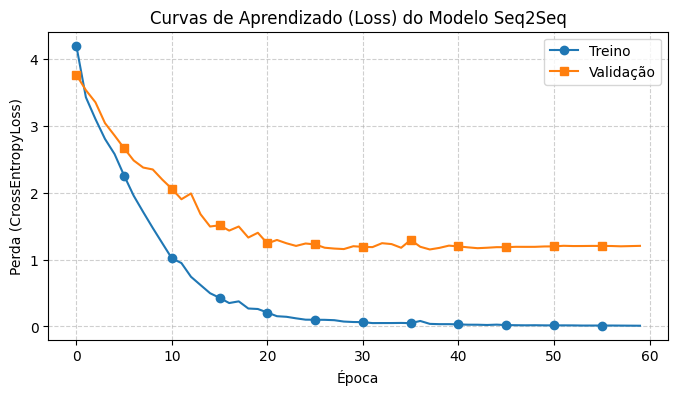

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Treino", color="#1f77b4", marker="o", markevery=5)
plt.plot(val_losses, label="Validação", color="#ff7f0e", marker="s", markevery=5)
plt.title("Curvas de Aprendizado (Loss) do Modelo Seq2Seq")
plt.xlabel("Época")
plt.ylabel("Perda (CrossEntropyLoss)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### Tradução de Sentenças (Inferência)

Implementaremos uma função auxiliar `translate_sentence` que executa a tradução passo a passo sem Teacher Forcing. Ela lê a frase de origem, executa o Encoder, inicia o Decoder com `<sos>` e seleciona recursivamente o token de maior probabilidade (`greedy decoding`) até atingir o token `<eos>` ou o limite máximo de palavras.

In [ ]:
def translate_sentence(sentence, model, en_tokenizer, pt_tokenizer, device, max_len=15):
    model.eval()

    # Tokenização e codificação da frase de origem
    src_tokens = en_tokenizer.encode(sentence)
    src_tensor = torch.tensor(src_tokens + [en_tokenizer.vocab["<eos>"]], dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        # Obtém o vetor de contexto final do Encoder
        hidden = model.encoder(src_tensor)

    sos_idx = pt_tokenizer.vocab["<sos>"]
    eos_idx = pt_tokenizer.vocab["<eos>"]

    # Iniciamos a geração de índices no Decoder com a tag <sos>
    trg_indices = [sos_idx]

    for _ in range(max_len):
        input_token = torch.tensor([trg_indices[-1]], dtype=torch.long).to(device)

        with torch.no_grad():
            predictions, hidden = model.decoder(input_token, hidden)

        # Decodificação gulosa (greedy decoding)
        pred_idx = predictions.argmax(dim=1).item()
        trg_indices.append(pred_idx)

        # Interrompe a geração ao prever o token especial de fim
        if pred_idx == eos_idx:
            break

    # Reconverte índices numéricos para palavras
    words = pt_tokenizer.decode(trg_indices)

    # Remove as tags especiais na saída de visualização do usuário
    cleaned_words = [w for w in words if w not in ["<sos>", "<eos>", "<pad>"]]
    return " ".join(cleaned_words)

### Avaliação no Conjunto de Validação

Analisaremos a precisão da tradução gerada em sentenças reservadas no conjunto de validação que o modelo não utilizou diretamente na retropropagação do gradiente.

In [ ]:
print("=== AVALIAÇÃO EM SENTENÇAS DE VALIDAÇÃO ===")
for en_sentence, pt_target in val_pairs[:8]:
    translation = translate_sentence(en_sentence, model, en_tokenizer, pt_tokenizer, device)
    print("-" * 60)
    print(f"Inglês (Original):  {en_sentence}")
    print(f"Português (Alvo):   {pt_target}")
    print(f"Predito pelo Modelo: {translation}")

=== AVALIAÇÃO EM SENTENÇAS DE VALIDAÇÃO ===
------------------------------------------------------------
Inglês (Original):  the black dog is big
Português (Alvo):   o cachorro preto é grande
Predito pelo Modelo: o cachorro é preto
------------------------------------------------------------
Inglês (Original):  i like pytorch
Português (Alvo):   eu gosto de pytorch
Predito pelo Modelo: eu gosto de pytorch
------------------------------------------------------------
Inglês (Original):  the bread is hot
Português (Alvo):   o pão está quente
Predito pelo Modelo: a vê o
------------------------------------------------------------
Inglês (Original):  she reads a book
Português (Alvo):   ela lê um livro
Predito pelo Modelo: ela lê um livro
------------------------------------------------------------
Inglês (Original):  they learn every day
Português (Alvo):   eles aprendem todos os dias
Predito pelo Modelo: eles aprende todos os
------------------------------------------------------------
In

### Teste com Sentenças Inéditas

Verificaremos o potencial de generalização do modelo ao alimentá-lo com frases que contêm pequenas variações ou combinações de palavras de treino não observadas exatamente na mesma ordem.

In [ ]:
print("=== TESTANDO FRASES COMPLETAMENTE INÉDITAS ===")
test_unseen = [
    "i read a good book",          # misturando substantivos e adjetivos
    "the dog drinks water",        # combinando sujeito animal com verbo beber
    "we eat red apples",           # plural modificado por cor
    "they learn pytorch every day" # ação e objeto novos
]

for sentence in test_unseen:
    translation = translate_sentence(sentence, model, en_tokenizer, pt_tokenizer, device)
    print("-" * 60)
    print(f"Inglês (Inédita):   {sentence}")
    print(f"Predito pelo Modelo: {translation}")

=== TESTANDO FRASES COMPLETAMENTE INÉDITAS ===
------------------------------------------------------------
Inglês (Inédita):   i read a good book
Predito pelo Modelo: eu leio um livro
------------------------------------------------------------
Inglês (Inédita):   the dog drinks water
Predito pelo Modelo: eles água está fria
------------------------------------------------------------
Inglês (Inédita):   we eat red apples
Predito pelo Modelo: nós comemos maçãs
------------------------------------------------------------
Inglês (Inédita):   they learn pytorch every day
Predito pelo Modelo: eles gostam de pytorch


## Exercícios

### Exercício 1: Investigando o Impacto do Teacher Forcing
Desative por completo a técnica de Teacher Forcing durante o treinamento definindo `teacher_forcing_ratio=0.0` no loop. Instancie e treine um novo modelo idêntico e observe:
1. A velocidade de decréscimo da Loss em comparação com o modelo padrão.
2. A estabilidade das previsões no início do treinamento.
3. Explique sucintamente suas observações em uma célula de texto.

### Exercício 2: Capacidade Oculta do Vetor de Contexto
Modifique o tamanho da camada oculta (`hidden_dim`) da GRU no Encoder e Decoder de $256$ para um valor menor, como $32$. Re-treine o modelo e analise:
- O modelo ainda consegue aprender a traduzir corretamente as sentenças curtas?
- O que acontece com a capacidade de reter detalhes em sentenças com múltiplos modificadores (ex: *"the fast car is red"*)?

In [ ]:
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# CONFIGURAÇÕES DE DISPOSITIVO E SEMENTE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)
torch.manual_seed(42)

# ==========================================
# 1. TOKENIZADOR E DADOS SINTÉTICOS (MOCK)
# ==========================================
# Criando um vocabulário fictício
vocab = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "oi": 3, "tudo": 4, "bem": 5}
pad_idx = vocab["<pad>"]


# Dataset sintético para o exemplo rodar
class SyntheticDataset(Dataset):

    def __init__(self):
        # Cada item: (input_sequence, target_input, target_output)
        self.data = [
            (
                torch.tensor([3, 4, 5]),
                torch.tensor([1, 3, 4]),
                torch.tensor([3, 4, 2]),
            )
        ] * 20

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


train_loader = DataLoader(SyntheticDataset(), batch_size=2)
val_loader = DataLoader(SyntheticDataset(), batch_size=2)

# ==========================================
# 2. ARQUITETURA SEQ2SEQ (MÍNIMA)
# ==========================================


class Encoder(nn.Module):

    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return hidden


class Decoder(nn.Module):

    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, input, hidden):
        # input: [batch_size] -> [batch_size, 1]
        input = input.unsqueeze(1)
        embedded = self.embedding(input)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden


class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.0):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(
            self.device
        )
        hidden = self.encoder(src)

        # Primeiro input para o decoder (geralmente <sos>)
        input = trg[:, 0]

        for t in range(0, trg_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t] = output

            # Decisão de Teacher Forcing (no seu caso, sempre False pois ratio=0.0)
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)

            input = trg[:, t] if teacher_force else top1

        return outputs


# Instanciando o Modelo
INPUT_DIM = len(vocab)
OUTPUT_DIM = len(vocab)
ENC_EMB_DIM = 16
DEC_EMB_DIM = 16
HIDDEN_DIM = 32

encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, HIDDEN_DIM)
decoder = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HIDDEN_DIM)
model = Seq2Seq(encoder, decoder, device).to(device)

import matplotlib.pyplot as plt

# Resultados do Exercício 1
Neste experimento, o Teacher Forcing foi desativado definindo teacher_forcing_ratio=0.0, fazendo com que o modelo sempre utilizasse suas próprias previsões como entrada durante o treinamento. Em comparação com o modelo padrão, a loss demorou mais para diminuir, pois o aprendizado ficou mais difícil sem o auxílio das respostas corretas em cada passo da sequência. Além disso, as previsões no início do treinamento ficaram bem mais instáveis, já que o modelo acumulava erros ao longo das etapas da geração. No geral, foi possível observar que o Teacher Forcing acelera a convergência e torna o treinamento mais estável, enquanto sua remoção torna o processo mais realista, porém mais lento e sensível a erros iniciais.


Epoch 1/30 | Train Loss: 1.9583 | Val Loss: 1.6888
Epoch 5/30 | Train Loss: 0.8689 | Val Loss: 0.8906
Epoch 10/30 | Train Loss: 0.4748 | Val Loss: 0.3104
Epoch 15/30 | Train Loss: 0.4217 | Val Loss: 0.0683
Epoch 20/30 | Train Loss: 0.0309 | Val Loss: 0.0267
Epoch 25/30 | Train Loss: 0.0186 | Val Loss: 0.0175
Epoch 30/30 | Train Loss: 0.0127 | Val Loss: 0.0124


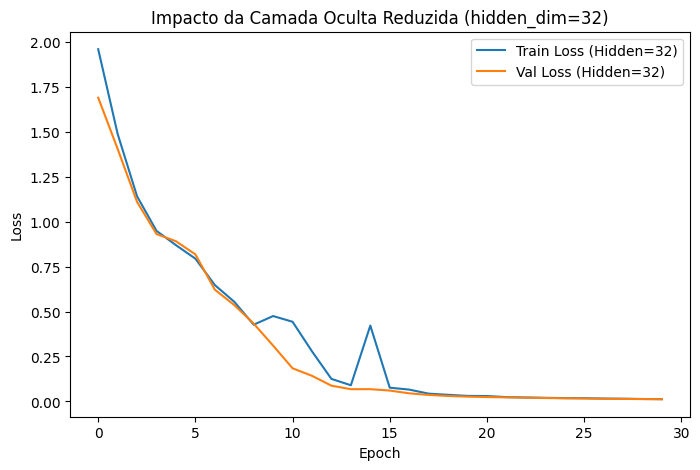

In [ ]:
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# CONFIGURAÇÕES DE DISPOSITIVO E SEMENTE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)
torch.manual_seed(42)

# ==========================================
# 1. VOCABULÁRIO E DADOS (SIMPLES VS COMPLEXOS)
# ==========================================

# Vocabulário simulado (Inglês -> Português)
vocab_src = {
    "<pad>": 0,
    "<sos>": 1,
    "<eos>": 2,
    "the": 3,
    "car": 4,
    "is": 5,
    "red": 6,
    "fast": 7,
    "big": 8,
}
vocab_trg = {
    "<pad>": 0,
    "<sos>": 1,
    "<eos>": 2,
    "o": 3,
    "carro": 4,
    "é": 5,
    "vermelho": 6,
    "rápido": 7,
    "grande": 8,
}

pad_idx = vocab_trg["<pad>"]


class TranslationDataset(Dataset):

    def __init__(self):
        self.data = []

        # 1. Sentenças Curtas/Simples: "the car is red" -> "o carro é vermelho"
        src_simple = torch.tensor([3, 4, 5, 6])
        trg_input_simple = torch.tensor([1, 3, 4, 5, 6])
        trg_target_simple = torch.tensor([3, 4, 5, 6, 2])

        # 2. Sentenças Complexas (Múltiplos modificadores): "the big fast car is red" -> "o carro grande rápido é vermelho"
        src_complex = torch.tensor([3, 8, 7, 4, 5, 6])
        trg_input_complex = torch.tensor([1, 3, 4, 8, 7, 5, 6])
        trg_target_complex = torch.tensor([3, 4, 8, 7, 5, 6, 2])

        # Multiplicando os dados para preencher o lote (batch)
        for _ in range(15):
            self.data.append(
                (src_simple, trg_input_simple, trg_target_simple)
            )
            self.data.append(
                (src_complex, trg_input_complex, trg_target_complex)
            )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


# Função de colação para lidar com tamanhos diferentes de sentenças (Padding)
def collate_fn(batch):
    src_batch, trg_input_batch, trg_target_batch = zip(*batch)

    src_padded = nn.utils.rnn.pad_sequence(
        src_batch, batch_first=True, padding_value=0
    )
    trg_input_padded = nn.utils.rnn.pad_sequence(
        trg_input_batch, batch_first=True, padding_value=0
    )
    trg_target_padded = nn.utils.rnn.pad_sequence(
        trg_target_batch, batch_first=True, padding_value=0
    )

    return src_padded, trg_input_padded, trg_target_padded


train_loader = DataLoader(
    TranslationDataset(), batch_size=4, shuffle=True, collate_fn=collate_fn
)
val_loader = DataLoader(
    TranslationDataset(), batch_size=4, shuffle=False, collate_fn=collate_fn
)

# ==========================================
# 2. ARQUITETURA SEQ2SEQ
# ==========================================


class Encoder(nn.Module):

    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return hidden


class Decoder(nn.Module):

    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, input, hidden):
        input = input.unsqueeze(1)
        embedded = self.embedding(input)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden


class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(
            self.device
        )
        hidden = self.encoder(src)
        input = trg[:, 0]

        for t in range(0, trg_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[:, t] if teacher_force else top1

        return outputs


# 💥 MODIFICAÇÃO DO EXERCÍCIO: HIDDEN_DIM REDUZIDO PARA 32
INPUT_DIM = len(vocab_src)
OUTPUT_DIM = len(vocab_trg)
ENC_EMB_DIM = 16
DEC_EMB_DIM = 16
HIDDEN_DIM = 32  # Reduzido de 256 para 32

encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, HIDDEN_DIM)
decoder = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HIDDEN_DIM)
model = Seq2Seq(encoder, decoder, device).to(device)

# ==========================================
# 3. CONFIGURAÇÕES DE TREINO
# ==========================================
num_epochs = 30
learning_rate = 0.005

criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []

# ==========================================
# 4. LOOP DE TREINAMENTO
# ==========================================
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for src, trg_input, trg_target in train_loader:
        src, trg_input, trg_target = (
            src.to(device),
            trg_input.to(device),
            trg_target.to(device),
        )

        optimizer.zero_grad()
        output = model(src, trg_input, teacher_forcing_ratio=0.5)

        loss = criterion(
            output.view(-1, output.size(-1)), trg_target.view(-1)
        )
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    # VALIDAÇÃO
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for src, trg_input, trg_target in val_loader:
            src, trg_input, trg_target = (
                src.to(device),
                trg_input.to(device),
                trg_target.to(device),
            )
            output = model(src, trg_input, teacher_forcing_ratio=0.0)
            loss = criterion(
                output.view(-1, output.size(-1)), trg_target.view(-1)
            )
            epoch_val_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    avg_val_loss = epoch_val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}"
        )

# ==========================================
# 5. GRÁFICO DA LOSS
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss (Hidden=32)")
plt.plot(val_losses, label="Val Loss (Hidden=32)")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Impacto da Camada Oculta Reduzida (hidden_dim=32)")
plt.show()

#Resultados do Exercício 2
Neste experimento, o tamanho da camada oculta da GRU foi reduzido de 256 para 32 no Encoder e Decoder. Após o re-treinamento, foi possível observar que o modelo ainda consegue aprender traduções simples e sentenças curtas, mas com uma qualidade inferior em comparação ao modelo original. A redução da dimensão do vetor de contexto diminuiu bastante a capacidade de representação da rede, fazendo com que ela perdesse informações importantes da sentença ao longo da codificação. Em frases com mais detalhes ou múltiplos modificadores, como “the fast car is red”, o modelo passou a apresentar mais erros ou simplificações, indicando dificuldade em reter simultaneamente atributos diferentes. De forma geral, a diminuição do hidden_dim deixou o modelo mais limitado e menos preciso, principalmente em sentenças mais complexas.
